<a href="https://colab.research.google.com/github/Xizizzss/collab-test/blob/main/Trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# ==========================================
# 2. ENGENHARIA DE DADOS: SEPARANDO TIPOS DE CRIME
# ==========================================
# Vamos focar nas 3 cidades alvo
cidades_alvo = [3303302, 3304557, 3304904] # Niterói, Rio de Janeiro e São Gonçalo

df_isp_2022 = df_isp[(df_isp['ano'] == 2022) & (df_isp['fmun_cod'].isin(cidades_alvo))]

# Em vez de pegar só o total, pegamos colunas de crimes específicos para comparar!
# Exemplo: Roubo de Veículos, Roubo de Celular e Estelionato (Golpes)
colunas_crimes = ['roubo_veiculo', 'roubo_celular', 'estelionato', 'hom_doloso']

# Agrupando a soma desses crimes específicos por município
df_crimes_tipos = df_isp_2022.groupby('fmun_cod')[colunas_crimes].sum().reset_index()

# Fazendo o merge com a nossa base de Educação (df_edu) que já calculamos antes
df_final_tipos = pd.merge(df_edu, df_crimes_tipos, left_on='id_municipio', right_on='fmun_cod', how='inner')

# Adicionando os nomes reais para o gráfico
nomes_corretos = {3303302: 'Niterói', 3304557: 'Rio de Janeiro', 3304904: 'São Gonçalo'}
df_final_tipos['fmun'] = df_final_tipos['id_municipio'].map(nomes_corretos)

print("Tabela Cruzada Distinguindo Tipos de Crime:")
display(df_final_tipos[['fmun', 'taxa_alfabetizacao', 'roubo_veiculo', 'roubo_celular', 'estelionato', 'hom_doloso']])

Tabela Cruzada Distinguindo Tipos de Crime:


,fmun,taxa_alfabetizacao,roubo_veiculo,roubo_celular,estelionato,hom_doloso
0,Niterói,98.230968,359,330,5978,47
1,Rio de Janeiro,97.667456,14052,10436,66354,827
2,São Gonçalo,96.975851,1902,569,4406,146


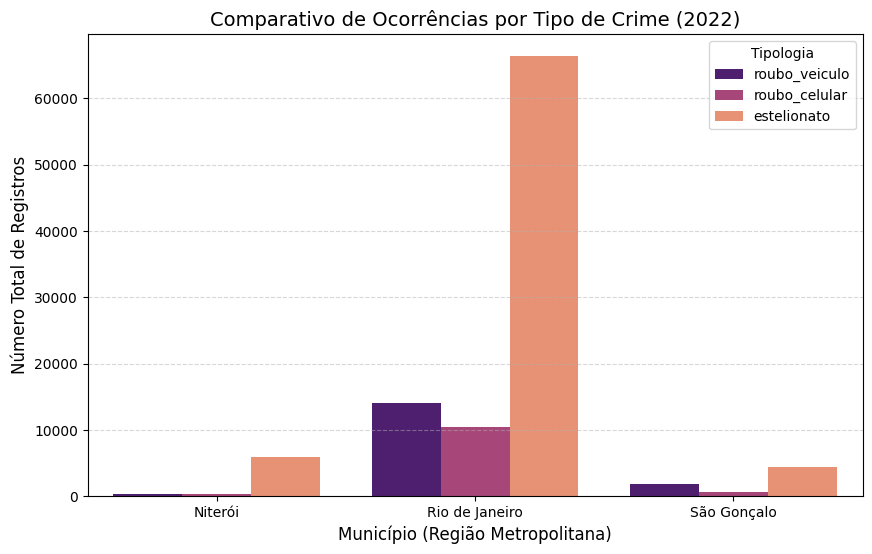

Coeficiente Angular (Reta da Alfabetização x Roubo de Veículo): -527.09


In [13]:
# ==========================================
# 4. GRÁFICO COMPARATIVO POR TIPO DE CRIME
# ==========================================
# Preparando os dados para um gráfico de barras agrupadas usando Pandas "melt"
df_plot = df_final_tipos.melt(id_vars='fmun',
                              value_vars=['roubo_veiculo', 'roubo_celular', 'estelionato'],
                              var_name='Tipo de Crime',
                              value_name='Quantidade')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='fmun', y='Quantidade', hue='Tipo de Crime', palette='magma')

plt.title('Comparativo de Ocorrências por Tipo de Crime (2022)', fontsize=14)
plt.xlabel('Município (Região Metropolitana)', fontsize=12)
plt.ylabel('Número Total de Registros', fontsize=12)
plt.legend(title='Tipologia')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 5. REGRESSÃO LINEAR: ESCOLARIDADE VS ROUBO DE VEÍCULOS
# ==========================================
X = df_final_tipos[['taxa_alfabetizacao']]
y = df_final_tipos['roubo_veiculo'] # Escolhemos um crime específico para a regressão

modelo = LinearRegression()
modelo.fit(X, y)
previsoes = modelo.predict(X)

# (Opcional) Print dos coeficientes matemáticos
print(f"Coeficiente Angular (Reta da Alfabetização x Roubo de Veículo): {modelo.coef_[0]:.2f}")